# CTG Fetal Heart-Rate Pattern Classification

Cardiotocogram (CTG) recordings capture fetal heart rate and uterine
contraction signals during pregnancy monitoring. The UCI **Cardiotocography**
dataset (2126 recordings) provides 21 numeric features extracted from each
signal, together with a morphologic pattern class (1-10) assigned by expert
obstetricians (FIGO classification).

**Goal:** predict the pattern class from the signal-derived features, and
identify which features drive the decision — a prerequisite for using such a
model as clinical decision support.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, learning_curve, train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
plt.style.use("default")
sns.set_palette("husl")
RANDOM_STATE = 42

## Load & clean data

In [2]:
FEATURE_COLUMNS = [
    "LB", "AC", "FM", "UC", "DL", "DS", "DP", "ASTV", "MSTV",
    "ALTV", "MLTV", "Width", "Min", "Max", "Nmax", "Nzeros",
    "Mode", "Mean", "Median", "Variance", "Tendency",
]
TARGET = "CLASS"

df = pd.read_csv("data/CTG.csv")
df = df[FEATURE_COLUMNS + [TARGET]].apply(pd.to_numeric, errors="coerce")
df[TARGET] = df[TARGET].astype("Int64")

print(f"Rows: {len(df)} | features: {len(FEATURE_COLUMNS)} | classes: {df[TARGET].nunique()}")

Rows: 2129 | features: 21 | classes: 10


## Exploratory analysis

In [3]:
class_counts = df[TARGET].value_counts().sort_index()
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Class distribution (%):")
print((class_counts / len(df) * 100).round(2).to_string())
print(f"\nMissing values: {'none' if missing.empty else missing.to_dict()}")

Class distribution (%):
CLASS
1     18.04
2      27.2
3      2.49
4       3.8
5      3.38
6     15.59
7     11.84
8      5.03
9      3.24
10     9.25

Missing values: {'LB': 3, 'AC': 3, 'FM': 2, 'UC': 2, 'DL': 1, 'DS': 1, 'DP': 1, 'ASTV': 2, 'MSTV': 2, 'ALTV': 2, 'MLTV': 2, 'Width': 3, 'Min': 3, 'Max': 3, 'Nmax': 3, 'Nzeros': 3, 'Mode': 3, 'Mean': 3, 'Median': 3, 'Variance': 3, 'Tendency': 3, 'CLASS': 3}


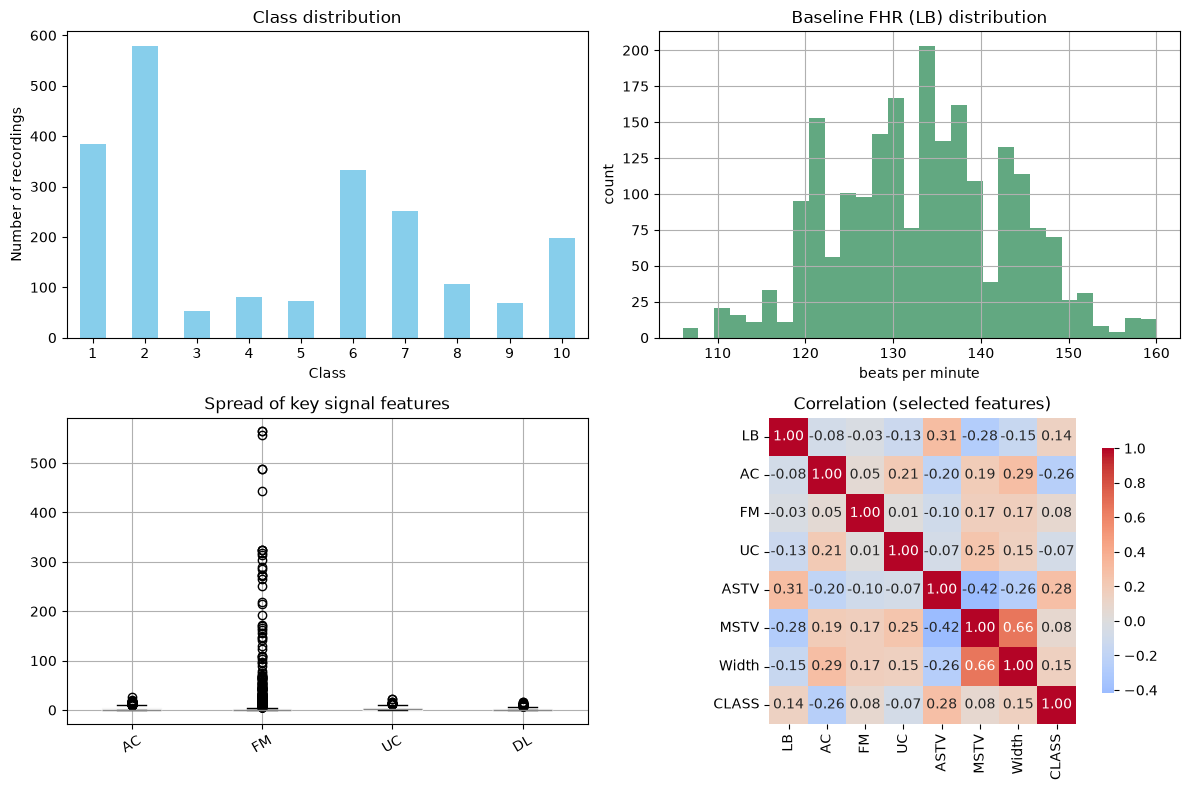

In [4]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
class_counts.plot(kind="bar", color="skyblue")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Number of recordings")
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
df["LB"].hist(bins=30, alpha=0.75, color="seagreen")
plt.title("Baseline FHR (LB) distribution")
plt.xlabel("beats per minute")
plt.ylabel("count")

plt.subplot(2, 2, 3)
df[["AC", "FM", "UC", "DL"]].boxplot()
plt.title("Spread of key signal features")
plt.xticks(rotation=30)

plt.subplot(2, 2, 4)
corr_subset = df[["LB", "AC", "FM", "UC", "ASTV", "MSTV", "Width", TARGET]].corr()
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0, square=True,
            fmt=".2f", cbar_kws={"shrink": 0.8})
plt.title("Correlation (selected features)")
plt.tight_layout()
plt.savefig("figures/eda_overview.png", dpi=130, bbox_inches="tight")
plt.show()

## Preprocessing — which representation works best?

Rows with missing values are dropped (only 3 out of 2129). Five
representations of the feature matrix are compared with a fast baseline
classifier (Gaussian Naive Bayes, 5-fold CV) before committing to one for the
full model comparison.

In [5]:
X = df[FEATURE_COLUMNS].dropna()
y = df.loc[X.index, TARGET].astype(int)
print(f"After dropping rows with missing values: {len(X)} samples ({len(df) - len(X)} removed)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns, index=X.index)
X_norm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns, index=X.index)

pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pd.DataFrame(pca.fit_transform(X_std), index=X.index)

selector = SelectKBest(f_classif, k=10)
X_sel = pd.DataFrame(selector.fit_transform(X, y),
                      columns=X.columns[selector.get_support()], index=X.index)

data_versions = {
    "original": X, "standardized": X_std, "normalized": X_norm,
    "pca_10": X_pca, "selectk_10": X_sel,
}
print(f"PCA(10) explained variance: {pca.explained_variance_ratio_.sum():.3f}")

baseline = pd.Series(
    {name: cross_val_score(GaussianNB(), Xv, y, cv=skf).mean()
     for name, Xv in data_versions.items()},
    name="cv_accuracy",
).sort_values(ascending=False)
print("\nBaseline (Naive Bayes) accuracy per data representation:")
print(baseline.round(4).to_string())

After dropping rows with missing values: 2126 samples (3 removed)
PCA(10) explained variance: 0.870



Baseline (Naive Bayes) accuracy per data representation:
pca_10          0.6021
original        0.5922
normalized      0.5579
selectk_10      0.5475
standardized    0.5428


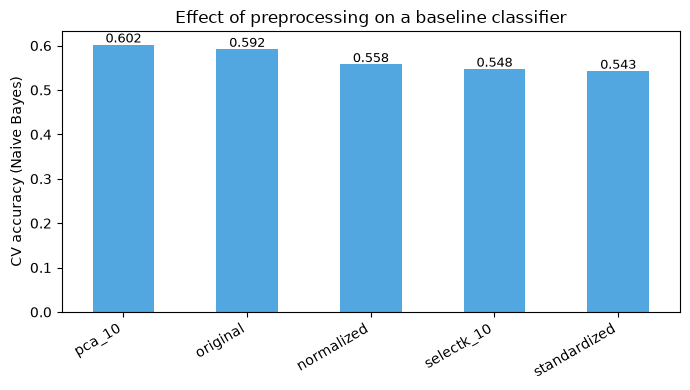

In [6]:
plt.figure(figsize=(7, 4))
baseline.plot(kind="bar", color="#3498db", alpha=0.85)
plt.ylabel("CV accuracy (Naive Bayes)")
plt.title("Effect of preprocessing on a baseline classifier")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(baseline.values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/preprocessing_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## Model comparison

Naive Bayes, Decision Tree, Random Forest, SVM and Gradient Boosting are
compared with 5-fold cross-validation. Tree-based models use the original
(unscaled) features — they don't need scaling and it avoids losing the
directly interpretable feature scale; SVM uses the PCA representation, which
it needs to perform reasonably.

In [7]:
candidates = [
    ("Naive Bayes", GaussianNB(), "original"),
    ("Decision Tree (default)", DecisionTreeClassifier(random_state=RANDOM_STATE), "original"),
    ("Decision Tree (tuned)",
     DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=RANDOM_STATE),
     "original"),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), "original"),
    ("SVM (RBF)", SVC(kernel="rbf", random_state=RANDOM_STATE), "pca_10"),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=RANDOM_STATE), "original"),
]

rows = []
for name, model, data_name in candidates:
    Xv = data_versions[data_name]
    cv_acc = cross_val_score(model, Xv, y, cv=skf, scoring="accuracy").mean()
    rows.append({"model": name, "data": data_name, "cv_accuracy": cv_acc})

results = pd.DataFrame(rows).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
print(results.round(4).to_string(index=False))

                  model     data  cv_accuracy
          Random Forest original       0.8979
      Gradient Boosting original       0.8876
  Decision Tree (tuned) original       0.8735
Decision Tree (default) original       0.8551
              SVM (RBF)   pca_10       0.7676
            Naive Bayes original       0.5922


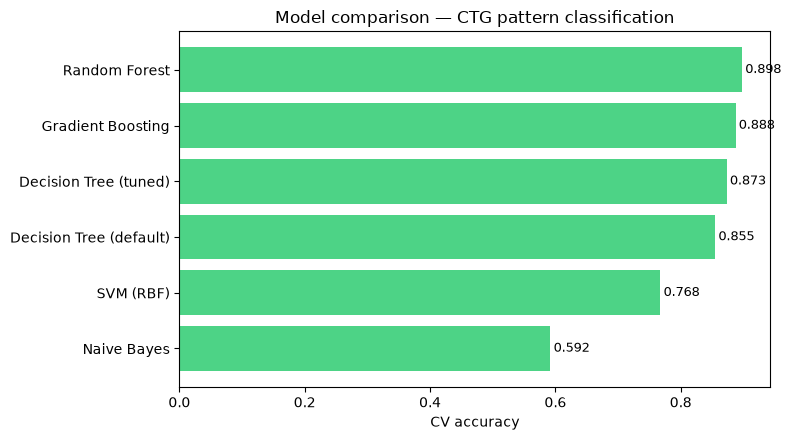

In [8]:
plt.figure(figsize=(8, 4.5))
plt.barh(results["model"], results["cv_accuracy"], color="#2ecc71", alpha=0.85)
plt.gca().invert_yaxis()
plt.xlabel("CV accuracy")
plt.title("Model comparison — CTG pattern classification")
for i, v in enumerate(results["cv_accuracy"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## Best model — detailed evaluation

In [9]:
best_name, best_data = results.iloc[0][["model", "data"]]
best_model = dict((n, m) for n, m, _ in candidates)[best_name]
Xb = data_versions[best_data]

X_train, X_test, y_train, y_test = train_test_split(
    Xb, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Best model: {best_name} on '{best_data}' data")
print(f"Held-out test accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred))

Best model: Random Forest on 'original' data
Held-out test accuracy: 0.8920

              precision    recall  f1-score   support

           1       0.89      0.95      0.92        77
           2       0.86      0.93      0.90       116
           3       1.00      0.45      0.62        11
           4       0.73      0.50      0.59        16
           5       0.75      0.43      0.55        14
           6       0.97      0.88      0.92        67
           7       0.94      0.98      0.96        51
           8       0.95      1.00      0.98        21
           9       0.88      1.00      0.93        14
          10       0.84      0.92      0.88        39

    accuracy                           0.89       426
   macro avg       0.88      0.80      0.82       426
weighted avg       0.89      0.89      0.89       426



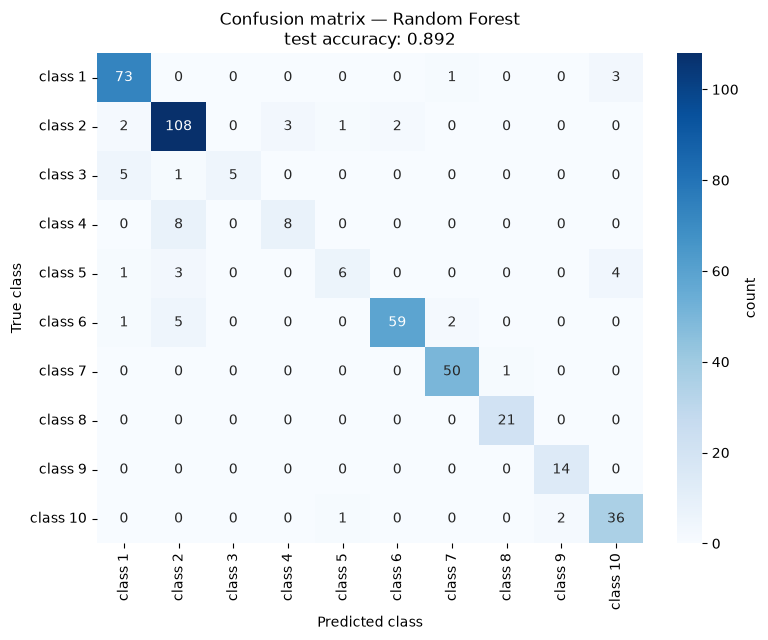

In [10]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"class {c}" for c in labels],
            yticklabels=[f"class {c}" for c in labels],
            cbar_kws={"label": "count"})
plt.title(f"Confusion matrix — {best_name}\ntest accuracy: {test_acc:.3f}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

## Feature importance & clinical interpretation

Even the strongest model is only useful in a clinical setting if the features
driving its decisions correspond to recognizable physiological signals.

In [11]:
MEDICAL_MEANING = {
    "LB": "Baseline fetal heart rate", "AC": "Accelerations", "FM": "Fetal movements",
    "UC": "Uterine contractions", "DL": "Light decelerations", "DS": "Severe decelerations",
    "DP": "Prolonged decelerations", "ASTV": "Short-term variability (abnormal, %)",
    "MSTV": "Mean short-term variability", "ALTV": "Long-term variability (abnormal, %)",
    "MLTV": "Mean long-term variability", "Width": "FHR histogram width",
    "Min": "FHR histogram minimum", "Max": "FHR histogram maximum",
    "Nmax": "Number of histogram peaks", "Nzeros": "Number of histogram zeros",
    "Mode": "FHR histogram mode", "Mean": "FHR histogram mean",
    "Median": "FHR histogram median", "Variance": "FHR histogram variance",
    "Tendency": "Histogram tendency",
}

if hasattr(best_model, "feature_importances_") and best_data == "original":
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=RANDOM_STATE)
    dt.fit(X, y)
    importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 5 features (clinical meaning):")
for feat, val in importance.head(5).items():
    print(f"  {feat:8} {val:.3f}  {MEDICAL_MEANING.get(feat, '')}")
print(f"\nTop 5 features account for {importance.head(5).sum()*100:.1f}% of total importance")

Top 5 features (clinical meaning):
  AC       0.185  Accelerations
  DL       0.126  Light decelerations
  Variance 0.082  FHR histogram variance
  ASTV     0.063  Short-term variability (abnormal, %)
  Mean     0.057  FHR histogram mean

Top 5 features account for 51.2% of total importance


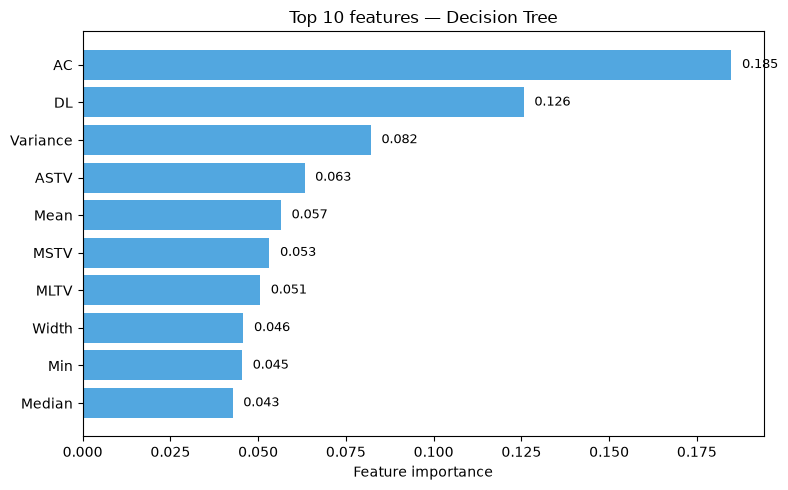

In [12]:
top10 = importance.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10.index[::-1], top10.values[::-1], color="#3498db", alpha=0.85)
plt.xlabel("Feature importance")
plt.title("Top 10 features — Decision Tree")
for i, v in enumerate(top10.values[::-1]):
    plt.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

## Model robustness — learning curve

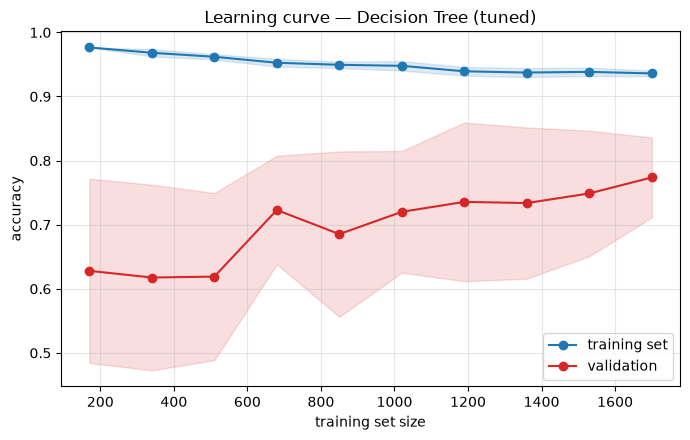

Learning curve gap (train - val) at full size: 0.1622


In [13]:
dt_tuned = DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    dt_tuned, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=RANDOM_STATE, scoring="accuracy",
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
gap = train_mean[-1] - val_mean[-1]

plt.figure(figsize=(7, 4.5))
plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="training set")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="tab:blue")
plt.plot(train_sizes, val_mean, "o-", color="tab:red", label="validation")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="tab:red")
plt.xlabel("training set size")
plt.ylabel("accuracy")
plt.title("Learning curve — Decision Tree (tuned)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/learning_curve.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Learning curve gap (train - val) at full size: {gap:.4f}")

## Key findings

- **Random Forest** is the strongest model (≈90% 5-fold CV accuracy, 89.2%
  held-out test accuracy), ahead of Gradient Boosting and a tuned Decision
  Tree; Naive Bayes and SVM trail well behind.
- The five rare classes (3, 4, 5, 9) are the hardest to separate — this is a
  class-imbalance problem, not just a modeling one, and the confusion matrix
  shows most errors land on adjacent, clinically-similar pattern classes.
- **Accelerations (AC)** and **light decelerations (DL)** dominate feature
  importance, followed by FHR variance and short-term variability (ASTV) —
  all standard obstetric signals, which supports the model as a plausible
  clinical decision-support tool rather than a black box.
- The learning curve shows a moderate train/validation gap (~0.16):
  more labeled data or regularization would likely help generalization
  further before considering clinical deployment.